# TABR final analysis

Single final model: `seed=11`

Sources:
- model dir: `third_party/tabular-dl-tabr-official/exp/tabr/convat_apex_anxiety/0-evaluation/11`
- dataset dir: `third_party/tabular-dl-tabr-official/data/convat_apex_anxiety`


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorboard.backend.event_processing import event_accumulator
from scipy.special import expit

sns.set_theme(style='whitegrid')
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
MODEL_DIR = ROOT / 'third_party/tabular-dl-tabr-official' / 'exp' / 'tabr' / 'convat_apex_anxiety' / '0-evaluation' / '11'
DATA_DIR = ROOT / 'third_party/tabular-dl-tabr-official' / 'data' / 'convat_apex_anxiety'
REPORT = json.loads((MODEL_DIR / 'report.json').read_text())
REPORT['metrics']['val']['score'], REPORT['metrics']['test']['score']


(0.7565372969997247, 0.7428256070640177)

In [2]:
def load_scalar_series(run_dir: Path, tag: str) -> pd.DataFrame:
    event_file = next(run_dir.glob('events.out.tfevents.*'))
    ea = event_accumulator.EventAccumulator(str(event_file))
    ea.Reload()
    scalars = ea.Scalars(tag)
    return pd.DataFrame({
        'epoch': [x.step for x in scalars],
        'value': [x.value for x in scalars],
        'wall_time': [x.wall_time for x in scalars],
    })

train_loss = load_scalar_series(MODEL_DIR / 'loss_train', 'loss')
val_score = load_scalar_series(MODEL_DIR / 'score_val', 'score')
test_score = load_scalar_series(MODEL_DIR / 'score_test', 'score')

display(train_loss.head())
display(val_score.head())
display(test_score.head())


,epoch,value,wall_time
0,0,0.564442,3.219227
1,1,0.482071,6.314219
2,2,0.431763,9.426741
3,3,0.399727,12.517225
4,4,0.376741,15.580267


,epoch,value,wall_time
0,0,0.656207,3.219825
1,1,0.671415,6.314271
2,2,0.685384,9.426793
3,3,0.686347,12.517277
4,4,0.691164,15.580318


,epoch,value,wall_time
0,0,0.668874,3.220372
1,1,0.692053,6.314289
2,2,0.682119,9.426811
3,3,0.689846,12.517307
4,4,0.675497,15.580348


## Curves available from official logs

Available directly from `bin/tabr.py` logs:
- train loss
- val score (accuracy for this dataset)
- test score (accuracy for this dataset)

Not logged per epoch in official code:
- val loss
- train accuracy


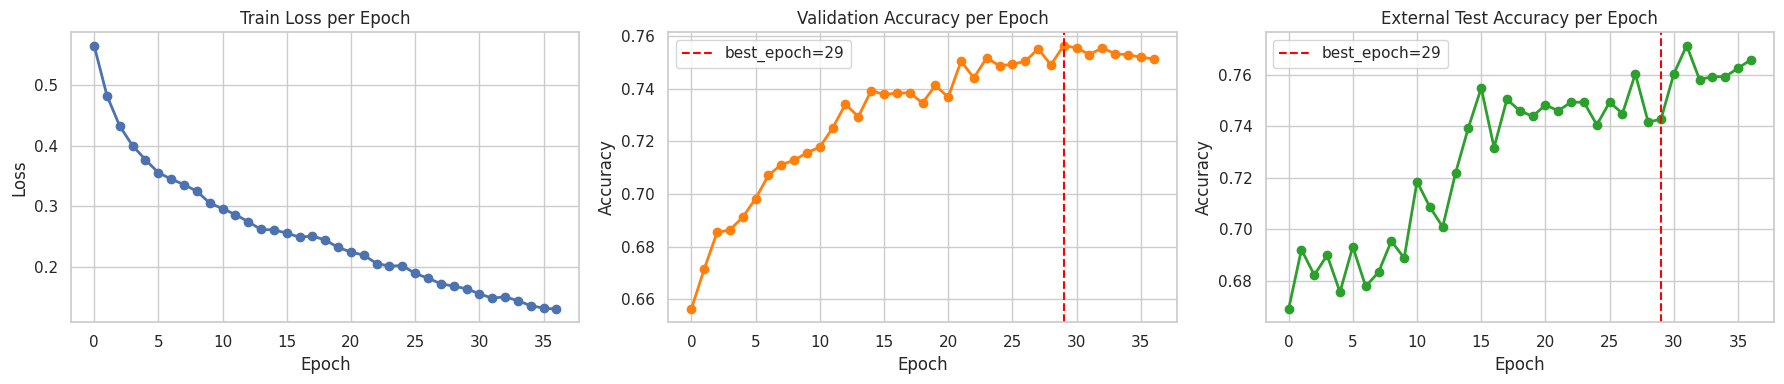

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(train_loss['epoch'], train_loss['value'], marker='o', linewidth=2)
axes[0].set_title('Train Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(val_score['epoch'], val_score['value'], marker='o', linewidth=2, color='tab:orange')
axes[1].axvline(REPORT['best_epoch'], linestyle='--', color='red', label=f"best_epoch={REPORT['best_epoch']}")
axes[1].set_title('Validation Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

axes[2].plot(test_score['epoch'], test_score['value'], marker='o', linewidth=2, color='tab:green')
axes[2].axvline(REPORT['best_epoch'], linestyle='--', color='red', label=f"best_epoch={REPORT['best_epoch']}")
axes[2].set_title('External Test Accuracy per Epoch')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()


In [4]:
predictions = np.load(MODEL_DIR / 'predictions.npz')
y_train = np.load(DATA_DIR / 'Y_train.npy')
y_val = np.load(DATA_DIR / 'Y_val.npy')
y_test = np.load(DATA_DIR / 'Y_test.npy')

pred_train = predictions['train']
pred_val = predictions['val']
pred_test = predictions['test']

yhat_train = (expit(pred_train) >= 0.5).astype(int)
yhat_val = (expit(pred_val) >= 0.5).astype(int)
yhat_test = (expit(pred_test) >= 0.5).astype(int)

labels = [0, 1]
label_names = ['anxiety_rendah', 'anxiety_tinggi']
cm_train = confusion_matrix(y_train, yhat_train, labels=labels)
cm_val = confusion_matrix(y_val, yhat_val, labels=labels)
cm_test = confusion_matrix(y_test, yhat_test, labels=labels)
cm_train, cm_val, cm_test


(array([[14195,   562],
        [  346, 19257]]),
 array([[4572, 1973],
        [1565, 6422]]),
 array([[231, 143],
        [ 90, 442]]))

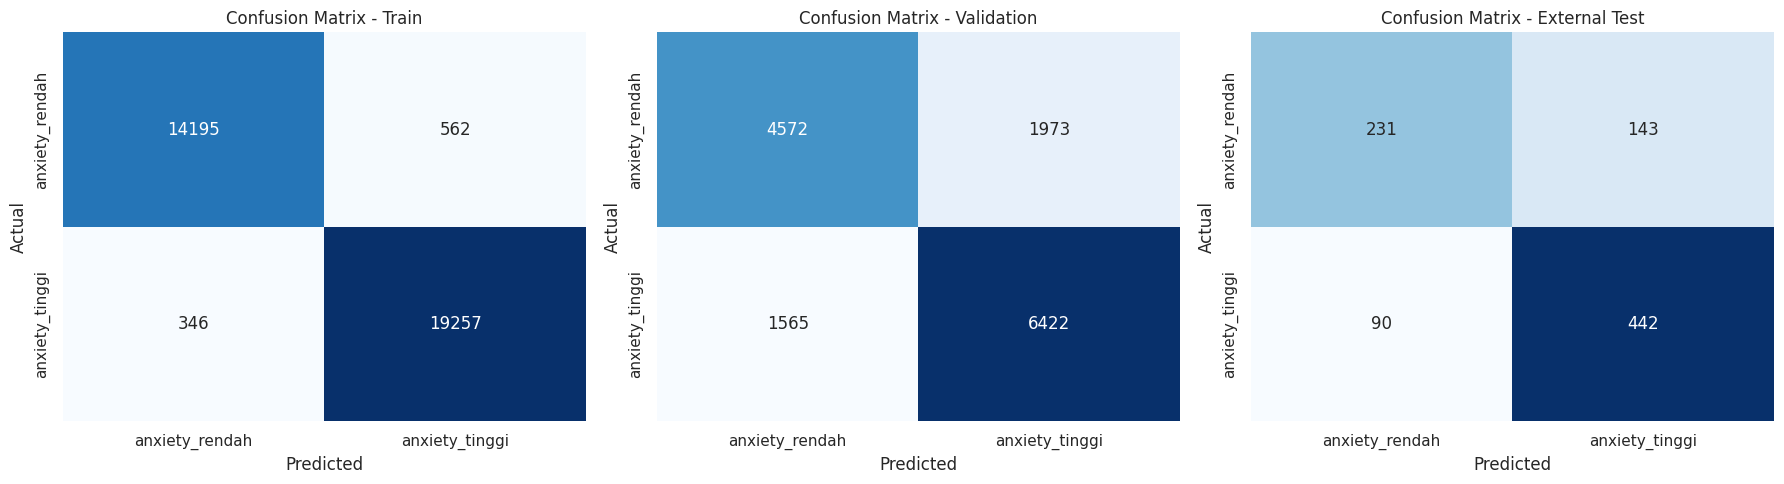

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cm, title in [
    (axes[0], cm_train, 'Confusion Matrix - Train'),
    (axes[1], cm_val, 'Confusion Matrix - Validation'),
    (axes[2], cm_test, 'Confusion Matrix - External Test'),
]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [9]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score

summary = pd.DataFrame([
    {'split': 'train', 'accuracy': (y_train == yhat_train).mean(), 'n': len(y_train)},
    {'split': 'val', 'accuracy': (y_val == yhat_val).mean(), 'n': len(y_val)},
    {'split': 'test_external', 'accuracy': (y_test == yhat_test).mean(), 'n': len(y_test)},
])
display(summary)

print('=== TRAIN CLASSIFICATION REPORT ===')
print(pd.DataFrame(classification_report(y_train, yhat_train, target_names=label_names, output_dict=True)).T)
print()
print('=== INTERNAL CLASSIFICATION REPORT ===')
print(pd.DataFrame(classification_report(y_val, yhat_val, target_names=label_names, output_dict=True)).T)
print()
print('=== EXTERNAL CLASSIFICATION REPORT ===')
print(pd.DataFrame(classification_report(y_test, yhat_test, target_names=label_names, output_dict=True)).T)

display(pd.DataFrame(cm_train, index=[f'true_{x}' for x in label_names], columns=[f'pred_{x}' for x in label_names]))
display(pd.DataFrame(cm_val, index=[f'true_{x}' for x in label_names], columns=[f'pred_{x}' for x in label_names]))
display(pd.DataFrame(cm_test, index=[f'true_{x}' for x in label_names], columns=[f'pred_{x}' for x in label_names]))

,split,accuracy,n
0,train,0.973574,34360
1,val,0.756537,14532
2,test_external,0.742826,906


=== TRAIN CLASSIFICATION REPORT ===
                precision    recall  f1-score       support
anxiety_rendah   0.976205  0.961916  0.969008  14757.000000
anxiety_tinggi   0.971643  0.982350  0.976967  19603.000000
accuracy         0.973574  0.973574  0.973574      0.973574
macro avg        0.973924  0.972133  0.972988  34360.000000
weighted avg     0.973603  0.973574  0.973549  34360.000000

=== INTERNAL CLASSIFICATION REPORT ===
                precision    recall  f1-score       support
anxiety_rendah   0.744989  0.698549  0.721022   6545.000000
anxiety_tinggi   0.764979  0.804057  0.784031   7987.000000
accuracy         0.756537  0.756537  0.756537      0.756537
macro avg        0.754984  0.751303  0.752527  14532.000000
weighted avg     0.755976  0.756537  0.755653  14532.000000

=== EXTERNAL CLASSIFICATION REPORT ===
                precision    recall  f1-score     support
anxiety_rendah   0.719626  0.617647  0.664748  374.000000
anxiety_tinggi   0.755556  0.830827  0.791406  5

,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,14195,562
true_anxiety_tinggi,346,19257


,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,4572,1973
true_anxiety_tinggi,1565,6422


,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,231,143
true_anxiety_tinggi,90,442


,selection_rule,threshold,val_accuracy,val_balanced_accuracy,val_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1
2,best_val_balanced_accuracy,0.555,0.755918,0.752367,0.752904,0.748344,0.732113,0.735453
0,default_0.5,0.500,0.756537,0.751303,0.752527,0.742826,0.724237,0.728077
1,best_val_accuracy,0.480,0.757363,0.751433,0.752905,0.742826,0.723046,0.727174
3,best_val_macro_f1,0.510,0.756881,0.751905,0.753037,0.742826,0.724237,0.728077


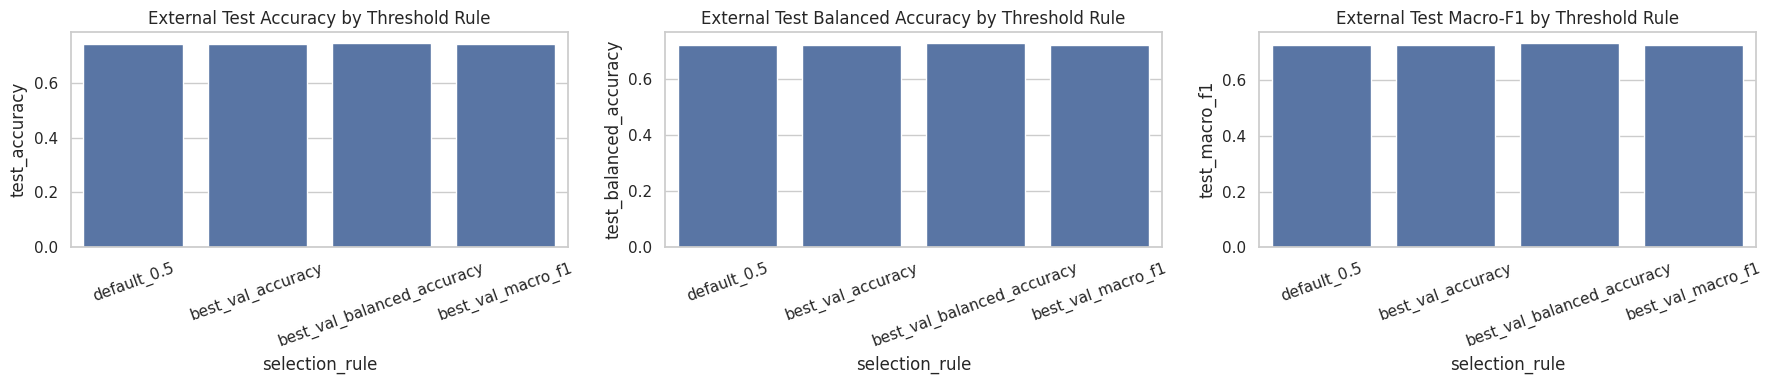

In [10]:
threshold_compare = []
for metric_name, thr in [('default_0.5', 0.5), ('best_val_accuracy', best_thr_acc), ('best_val_balanced_accuracy', best_thr_bacc), ('best_val_macro_f1', best_thr_f1)]:
    val_pred_thr = (val_prob >= thr).astype(int)
    test_pred_thr = (test_prob >= thr).astype(int)
    threshold_compare.append({
        'selection_rule': metric_name,
        'threshold': float(thr),
        'val_accuracy': float(accuracy_score(y_val, val_pred_thr)),
        'val_balanced_accuracy': float(balanced_accuracy_score(y_val, val_pred_thr)),
        'val_macro_f1': float(f1_score(y_val, val_pred_thr, average='macro')),
        'test_accuracy': float(accuracy_score(y_test, test_pred_thr)),
        'test_balanced_accuracy': float(balanced_accuracy_score(y_test, test_pred_thr)),
        'test_macro_f1': float(f1_score(y_test, test_pred_thr, average='macro')),
    })
threshold_compare_df = pd.DataFrame(threshold_compare)
display(threshold_compare_df.sort_values('test_accuracy', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.barplot(data=threshold_compare_df, x='selection_rule', y='test_accuracy', ax=axes[0])
sns.barplot(data=threshold_compare_df, x='selection_rule', y='test_balanced_accuracy', ax=axes[1])
sns.barplot(data=threshold_compare_df, x='selection_rule', y='test_macro_f1', ax=axes[2])
axes[0].set_title('External Test Accuracy by Threshold Rule')
axes[1].set_title('External Test Balanced Accuracy by Threshold Rule')
axes[2].set_title('External Test Macro-F1 by Threshold Rule')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


In [15]:
import os
import sys
import torch

TABR_ROOT = ROOT / 'third_party' / 'tabular-dl-tabr-official'
os.environ['PROJECT_DIR'] = str(TABR_ROOT)
if str(TABR_ROOT) not in sys.path:
    sys.path.append(str(TABR_ROOT))

import lib
from bin.tabr import Model

FINAL_THRESHOLD = 0.555
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
config = lib.load_config(MODEL_DIR.parent / '11.toml')
dataset = lib.build_dataset(**config['data']).to_torch(device)
model = Model(
    n_num_features=dataset.n_num_features,
    n_bin_features=dataset.n_bin_features,
    cat_cardinalities=dataset.cat_cardinalities(),
    n_classes=dataset.n_classes(),
    **config['model'],
).to(device)
checkpoint = lib.load_checkpoint(MODEL_DIR)
model.load_state_dict(checkpoint['model'])
model.eval()
train_indices = torch.arange(dataset.size('train'), device=device)

def get_Xy(part: str, idx=None):
    batch = (
        {key[2:]: dataset.data[key][part] for key in dataset.data if key.startswith('X_')},
        dataset.Y[part],
    )
    if idx is None:
        return batch
    return ({k: v[idx] for k, v in batch[0].items()}, batch[1][idx])

@torch.inference_mode()
def predict_part(part: str, eval_batch_size: int = 32768):
    preds = []
    for idx in torch.arange(dataset.size(part), device=device).split(eval_batch_size):
        x, _ = get_Xy(part, idx)
        candidate_x, candidate_y = get_Xy('train', None)
        logits = model(
            x_=x,
            y=None,
            candidate_x_=candidate_x,
            candidate_y=candidate_y,
            context_size=config['context_size'],
            is_train=False,
        ).squeeze(-1)
        preds.append(logits.detach().cpu())
    logits = torch.cat(preds).numpy()
    probs = expit(logits)
    labels = (probs >= FINAL_THRESHOLD).astype(int)
    return pd.DataFrame({
        'index': np.arange(len(logits)),
        'logit': logits,
        'prob_anxiety_tinggi': probs,
        'pred_label': labels,
        'pred_name': np.where(labels == 1, 'anxiety_tinggi', 'anxiety_rendah'),
    })

pred_from_model_test = predict_part('test')
display(pred_from_model_test.head())
print('n_test =', len(pred_from_model_test))
print('threshold =', FINAL_THRESHOLD)


2026-03-25 08:31:21.457 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


,index,logit,prob_anxiety_tinggi,pred_label,pred_name
0,0,4.437636,0.988314,1,anxiety_tinggi
1,1,4.037468,0.982664,1,anxiety_tinggi
2,2,5.780396,0.996922,1,anxiety_tinggi
3,3,5.126498,0.994098,1,anxiety_tinggi
4,4,4.130840,0.984185,1,anxiety_tinggi


n_test = 906
threshold = 0.555
